**# CELL 1: Setup & Imports**

In [1]:
import os
import shutil
import random
import json
from datetime import datetime
from collections import OrderedDict, Counter
import time

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader

# Set random seeds
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

print("✅ Libraries imported")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")


✅ Libraries imported
PyTorch: 2.6.0+cu124, CUDA: True


**# CELL 2: Configuration & Helper Functions**

In [2]:
# Paths (Kaggle-specific)
working_base = '/kaggle/working/MobilePlantViT'
data_dir = os.path.join(working_base, 'data')
master_directory_path = os.path.join(data_dir, 'PlantVillage_Master')
split_directory_path = os.path.join(data_dir, 'PlantVillage_Split')

# Directories
train_dir = os.path.join(split_directory_path, 'train')
val_dir = os.path.join(split_directory_path, 'val')
test_dir = os.path.join(split_directory_path, 'test')

# Split ratios
SPLIT_RATIO = {'train': 0.70, 'val': 0.15, 'test': 0.15}

# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# DataLoader settings
BATCH_SIZE = 64
NUM_WORKERS = 4
PIN_MEMORY = True


def count_images_in_dir(directory):
    """Count total images and classes in a directory."""
    total_images = 0
    class_distribution = OrderedDict()
    
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            class_distribution[class_name] = len(images)
            total_images += len(images)
    
    return total_images, class_distribution


def print_section(title):
    """Print formatted section header."""
    print("\n" + "=" * 80)
    print(f"  {title}")
    print("=" * 80)


print("✅ Configuration set")



✅ Configuration set


**# CELL 3: Dataset Discovery & Verification**

In [3]:
print_section("DATASET DISCOVERY")

# Find PlantVillage dataset in Kaggle input
possible_paths = [
    '/kaggle/input/plantvillage-dataset',
    '/kaggle/input/plant-village-dataset',
    '/kaggle/input/plantvillage'
]

dataset_input_path = None
for path in possible_paths:
    if os.path.exists(path):
        dataset_input_path = path
        break

if not dataset_input_path:
    for item in os.listdir('/kaggle/input'):
        if 'plant' in item.lower():
            dataset_input_path = os.path.join('/kaggle/input', item)
            break

# Find class directory (the one containing actual class folders)
def find_class_directory(base_path):
    for root, dirs, files in os.walk(base_path):
        if dirs and any('___' in d or 'leaf' in d.lower() for d in dirs):
            for dir_name in dirs[:2]:
                test_path = os.path.join(root, dir_name)
                if os.path.isdir(test_path):
                    test_files = os.listdir(test_path)
                    if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in test_files):
                        return root
    return base_path

DATASET_PATH = find_class_directory(dataset_input_path)

# Count and display dataset info
total_images, class_distribution = count_images_in_dir(DATASET_PATH)
CLASS_NAMES = list(class_distribution.keys())
NUM_CLASSES = len(CLASS_NAMES)

print(f"✅ Dataset found at: {DATASET_PATH}")
print(f"   Classes: {NUM_CLASSES}")
print(f"   Total Images: {total_images:,}")
print(f"   Avg per Class: {total_images/NUM_CLASSES:.0f}")



  DATASET DISCOVERY
✅ Dataset found at: /kaggle/input/plantvillage-dataset/segmented
   Classes: 38
   Total Images: 54,306
   Avg per Class: 1429


**# CELL 4: Create Master Directory & Copy Images**

In [4]:
print_section("MASTER DIRECTORY CREATION")

os.makedirs(master_directory_path, exist_ok=True)

print("Copying images to master directory...")
total_copied = 0

for class_name in tqdm(CLASS_NAMES, desc="Copying classes"):
    src_path = os.path.join(DATASET_PATH, class_name)
    dst_path = os.path.join(master_directory_path, class_name)
    os.makedirs(dst_path, exist_ok=True)
    
    images = [f for f in os.listdir(src_path) 
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for img in images:
        src_file = os.path.join(src_path, img)
        dst_file = os.path.join(dst_path, img)
        if not os.path.exists(dst_file):
            shutil.copy2(src_file, dst_file)
            total_copied += 1

# Verify
master_total, master_dist = count_images_in_dir(master_directory_path)

print(f"✅ Master directory created")
print(f"   Copied: {total_copied:,} images")
print(f"   Verified: {master_total:,} images")



  MASTER DIRECTORY CREATION
Copying images to master directory...


Copying classes:   0%|          | 0/38 [00:00<?, ?it/s]

✅ Master directory created
   Copied: 54,306 images
   Verified: 54,306 images


**# CELL 5: Create Split Directories**

In [5]:
print_section("SPLIT DIRECTORY CREATION")

# Create main split directories
for split_dir in [train_dir, val_dir, test_dir]:
    os.makedirs(split_dir, exist_ok=True)

# Create class folders in each split
for class_name in CLASS_NAMES:
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

print(f"✅ Split directories created")
print(f"   Train: {train_dir}")
print(f"   Val:   {val_dir}")
print(f"   Test:  {test_dir}")



  SPLIT DIRECTORY CREATION
✅ Split directories created
   Train: /kaggle/working/MobilePlantViT/data/PlantVillage_Split/train
   Val:   /kaggle/working/MobilePlantViT/data/PlantVillage_Split/val
   Test:  /kaggle/working/MobilePlantViT/data/PlantVillage_Split/test


**# CELL 6: Split Dataset into Train/Val/Test**

In [6]:
print_section("SPLITTING DATASET (70/15/15)")

split_stats = {
    'total_images': 0,
    'train_images': 0,
    'val_images': 0,
    'test_images': 0
}

for class_name in tqdm(CLASS_NAMES, desc="Splitting"):
    class_source_path = os.path.join(master_directory_path, class_name)
    
    # Get all images
    images = sorted([f for f in os.listdir(class_source_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    
    # Shuffle
    random.shuffle(images)
    
    # Calculate split indices
    total = len(images)
    train_count = int(total * SPLIT_RATIO['train'])
    val_count = int(total * SPLIT_RATIO['val'])
    
    # Split
    train_imgs = images[:train_count]
    val_imgs = images[train_count:train_count + val_count]
    test_imgs = images[train_count + val_count:]
    
    # Copy to respective directories
    for img in train_imgs:
        shutil.copy2(os.path.join(class_source_path, img),
                    os.path.join(train_dir, class_name, img))
    for img in val_imgs:
        shutil.copy2(os.path.join(class_source_path, img),
                    os.path.join(val_dir, class_name, img))
    for img in test_imgs:
        shutil.copy2(os.path.join(class_source_path, img),
                    os.path.join(test_dir, class_name, img))
    
    # Update stats
    split_stats['total_images'] += total
    split_stats['train_images'] += len(train_imgs)
    split_stats['val_images'] += len(val_imgs)
    split_stats['test_images'] += len(test_imgs)

print(f"✅ Dataset split complete")
print(f"   Total:  {split_stats['total_images']:,}")
print(f"   Train:  {split_stats['train_images']:,} ({split_stats['train_images']/split_stats['total_images']*100:.1f}%)")
print(f"   Val:    {split_stats['val_images']:,} ({split_stats['val_images']/split_stats['total_images']*100:.1f}%)")
print(f"   Test:   {split_stats['test_images']:,} ({split_stats['test_images']/split_stats['total_images']*100:.1f}%)")



  SPLITTING DATASET (70/15/15)


Splitting:   0%|          | 0/38 [00:00<?, ?it/s]

✅ Dataset split complete
   Total:  54,306
   Train:  37,997 (70.0%)
   Val:    8,129 (15.0%)
   Test:   8,180 (15.1%)


**# CELL 7: Define Transformations**

In [7]:
print_section("PREPROCESSING PIPELINE")

# Training transform (WITH augmentations)
transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), 
                           scale=(0.9, 1.1), shear=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, 
                          saturation=0.2, hue=0.1),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Val/Test transform (NO augmentations)
transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print(f"✅ Transforms defined")
print(f"   Train:    {len(transform_train.transforms)} steps (WITH augmentations)")
print(f"   Val/Test: {len(transform_val_test.transforms)} steps (NO augmentations)")



  PREPROCESSING PIPELINE
✅ Transforms defined
   Train:    9 steps (WITH augmentations)
   Val/Test: 3 steps (NO augmentations)


**# CELL 8: Create Datasets**

In [8]:
print_section("DATASET CREATION")

train_dataset = datasets.ImageFolder(train_dir, transform=transform_train)
val_dataset = datasets.ImageFolder(val_dir, transform=transform_val_test)
test_dataset = datasets.ImageFolder(test_dir, transform=transform_val_test)

print(f"✅ Datasets created")
print(f"   Train: {len(train_dataset):,} images")
print(f"   Val:   {len(val_dataset):,} images")
print(f"   Test:  {len(test_dataset):,} images")
print(f"   Classes: {len(train_dataset.classes)}")



  DATASET CREATION
✅ Datasets created
   Train: 37,997 images
   Val:   8,129 images
   Test:  8,180 images
   Classes: 38


**# CELL 9: Create DataLoaders**

In [9]:
print_section("DATALOADER CREATION")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    prefetch_factor=2,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    prefetch_factor=2,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    prefetch_factor=2,
    persistent_workers=True
)

print(f"✅ DataLoaders created")
print(f"   Train: {len(train_loader)} batches (shuffle=True)")
print(f"   Val:   {len(val_loader)} batches (shuffle=False)")
print(f"   Test:  {len(test_loader)} batches (shuffle=False)")



  DATALOADER CREATION
✅ DataLoaders created
   Train: 594 batches (shuffle=True)
   Val:   128 batches (shuffle=False)
   Test:  128 batches (shuffle=False)


**# CELL 10: Visualization - Sample Images**


  SAMPLE VISUALIZATION


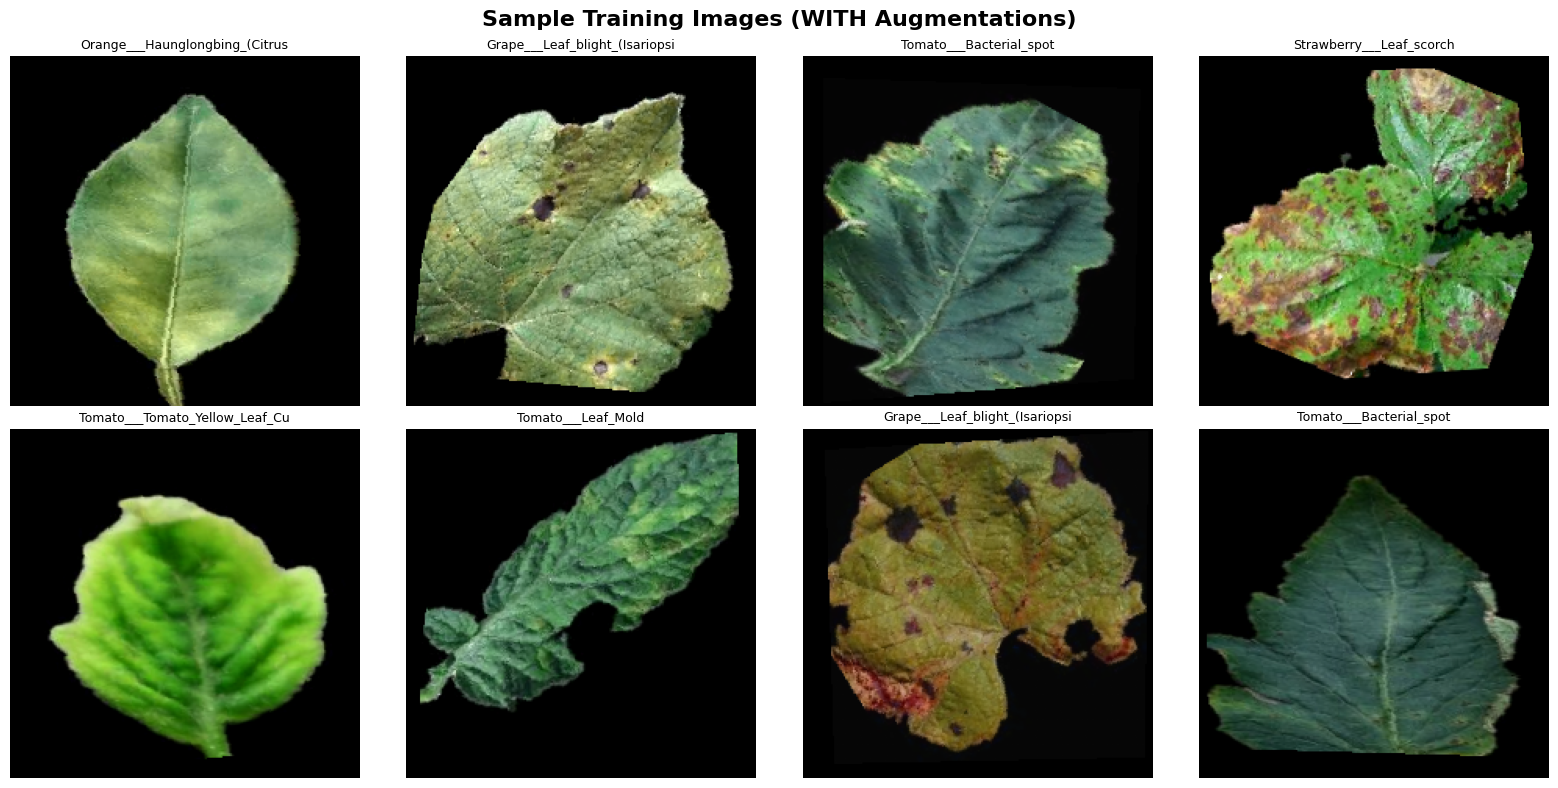

✅ Sample images displayed


In [10]:
print_section("SAMPLE VISUALIZATION")

def denormalize(tensor):
    """Denormalize tensor for visualization."""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, IMAGENET_MEAN, IMAGENET_STD):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

# Get sample batch
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Training Images (WITH Augmentations)', 
             fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    img = denormalize(images[idx])
    img = img.permute(1, 2, 0).numpy()
    
    ax.imshow(img)
    class_name = train_dataset.classes[labels[idx]]
    ax.set_title(class_name[:30], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("✅ Sample images displayed")


**# CELL 11: Model Setup (Verification)**

In [11]:
print_section("MODEL SETUP")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MobileNetV2
model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(device)

# Model stats
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model loaded: MobileNetV2")
print(f"   Device: {device}")
print(f"   Parameters: {total_params:,}")
print(f"   Output Classes: {NUM_CLASSES}")



  MODEL SETUP


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 151MB/s]

✅ Model loaded: MobileNetV2
   Device: cuda
   Parameters: 2,272,550
   Output Classes: 38


**# CELL 12: Pipeline Verification**

In [12]:
print_section("PIPELINE VERIFICATION")

model.eval()

# Test forward pass
images_batch, labels_batch = next(iter(train_loader))
images_batch = images_batch.to(device)
labels_batch = labels_batch.to(device)

with torch.no_grad():
    start = time.time()
    outputs = model(images_batch)
    forward_time = time.time() - start
    
    _, predictions = torch.max(outputs, 1)

print(f"✅ Forward pass successful")
print(f"   Input shape:  {tuple(images_batch.shape)}")
print(f"   Output shape: {tuple(outputs.shape)}")
print(f"   Time: {forward_time*1000:.2f} ms")
print(f"   Throughput: {len(images_batch)/forward_time:.1f} images/sec")



  PIPELINE VERIFICATION
✅ Forward pass successful
   Input shape:  (64, 3, 224, 224)
   Output shape: (64, 38)
   Time: 931.10 ms
   Throughput: 68.7 images/sec


**# CELL 13: Complete Pipeline Summary**

In [13]:
print("\n" + "=" * 80)
print("  COMPLETE PIPELINE SUMMARY")
print("=" * 80)

summary = f"""
📊 Dataset Configuration:
   • Source: PlantVillage (Kaggle)
   • Classes: {NUM_CLASSES}
   • Total Images: {split_stats['total_images']:,}
   • Train: {split_stats['train_images']:,} ({split_stats['train_images']/split_stats['total_images']*100:.1f}%)
   • Val:   {split_stats['val_images']:,} ({split_stats['val_images']/split_stats['total_images']*100:.1f}%)
   • Test:  {split_stats['test_images']:,} ({split_stats['test_images']/split_stats['total_images']*100:.1f}%)

🔄 Data Pipeline:
   • Batch Size: {BATCH_SIZE}
   • Workers: {NUM_WORKERS}
   • Train Batches: {len(train_loader):,}
   • Val Batches: {len(val_loader):,}
   • Test Batches: {len(test_loader):,}

🎨 Transformations:
   • Training: 9 steps WITH augmentations
   • Val/Test: 3 steps NO augmentations
   • Normalization: ImageNet statistics

🤖 Model:
   • Architecture: MobileNetV2
   • Parameters: {total_params:,}
   • Device: {device}
   • Output: {NUM_CLASSES} classes

✅ Pipeline Status: READY FOR TRAINING
"""

print(summary)
print("=" * 80)



  COMPLETE PIPELINE SUMMARY

📊 Dataset Configuration:
   • Source: PlantVillage (Kaggle)
   • Classes: 38
   • Total Images: 54,306
   • Train: 37,997 (70.0%)
   • Val:   8,129 (15.0%)
   • Test:  8,180 (15.1%)

🔄 Data Pipeline:
   • Batch Size: 64
   • Workers: 4
   • Train Batches: 594
   • Val Batches: 128
   • Test Batches: 128

🎨 Transformations:
   • Training: 9 steps WITH augmentations
   • Val/Test: 3 steps NO augmentations
   • Normalization: ImageNet statistics

🤖 Model:
   • Architecture: MobileNetV2
   • Parameters: 2,272,550
   • Device: cuda
   • Output: 38 classes

✅ Pipeline Status: READY FOR TRAINING



**# CELL 14: Training Loop**

In [14]:
print_section("TRAINING LOOP")

# Setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                       factor=0.5, patience=3)

NUM_EPOCHS = 10  # Adjust as needed
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)
    
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    
    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
    
    # Calculate training metrics
    train_loss = train_loss / len(train_dataset)
    train_acc = train_correct / len(train_dataset)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
    
    # Calculate validation metrics
    val_loss = val_loss / len(val_dataset)
    val_acc = val_correct / len(val_dataset)
    
    # Print epoch results
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✅ Model saved (val_acc: {val_acc:.4f})")

print(f"\n🎉 Training complete! Best Val Acc: {best_val_acc:.4f}")


  TRAINING LOOP

Epoch 1/10
------------------------------------------------------------


Training:   0%|          | 0/594 [00:00<?, ?it/s]

Validation:   0%|          | 0/128 [00:00<?, ?it/s]

Train Loss: 0.4269 | Train Acc: 0.8660
Val Loss:   0.1825 | Val Acc:   0.9416
✅ Model saved (val_acc: 0.9416)

Epoch 2/10
------------------------------------------------------------


Training:   0%|          | 0/594 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/128 [00:00<?, ?it/s]

Train Loss: 0.1074 | Train Acc: 0.9650
Val Loss:   0.0846 | Val Acc:   0.9713

Epoch 10/10
------------------------------------------------------------


Training:   0%|          | 0/594 [00:00<?, ?it/s]

Validation:   0%|          | 0/128 [00:00<?, ?it/s]

Train Loss: 0.1015 | Train Acc: 0.9669
Val Loss:   0.0672 | Val Acc:   0.9787
✅ Model saved (val_acc: 0.9787)

🎉 Training complete! Best Val Acc: 0.9787


**Evaluate on Test Set**

In [15]:
print_section("TEST SET EVALUATION")

# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_loss = 0.0
test_correct = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        test_correct += (preds == labels).sum().item()
        
        # Store for confusion matrix later
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate metrics
test_loss = test_loss / len(test_dataset)
test_acc = test_correct / len(test_dataset)

print(f"✅ Test Set Results:")
print(f"   Test Loss:     {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc*100:.2f}%")
print(f"   Total Images:  {len(test_dataset):,}")
print(f"   Correct:       {test_correct:,}")
print(f"   Incorrect:     {len(test_dataset) - test_correct:,}")


  TEST SET EVALUATION


Testing:   0%|          | 0/128 [00:00<?, ?it/s]

✅ Test Set Results:
   Test Loss:     0.0559
   Test Accuracy: 98.36%
   Total Images:  8,180
   Correct:       8,046
   Incorrect:     134


**Document Your Baseline Performance**

In [16]:
print_section("BASELINE MODEL PERFORMANCE")

baseline_results = {
    'model_name': 'MobileNetV2 (Baseline)',
    'best_val_accuracy': best_val_acc,
    'num_epochs': NUM_EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': 0.001,
    'optimizer': 'Adam',
    'total_params': total_params,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

print(f"✅ Baseline Training Complete")
print(f"   Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"   Model Saved: best_model.pth")
print(f"   Total Parameters: {total_params:,}")

# Save results to JSON for comparison later
import json
with open('baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=4)

print("\n📝 Results saved to baseline_results.json")


  BASELINE MODEL PERFORMANCE
✅ Baseline Training Complete
   Best Validation Accuracy: 97.87%
   Model Saved: best_model.pth
   Total Parameters: 2,272,550

📝 Results saved to baseline_results.json


**Create Confusion Matrix**


  CONFUSION MATRIX & CLASSIFICATION REPORT


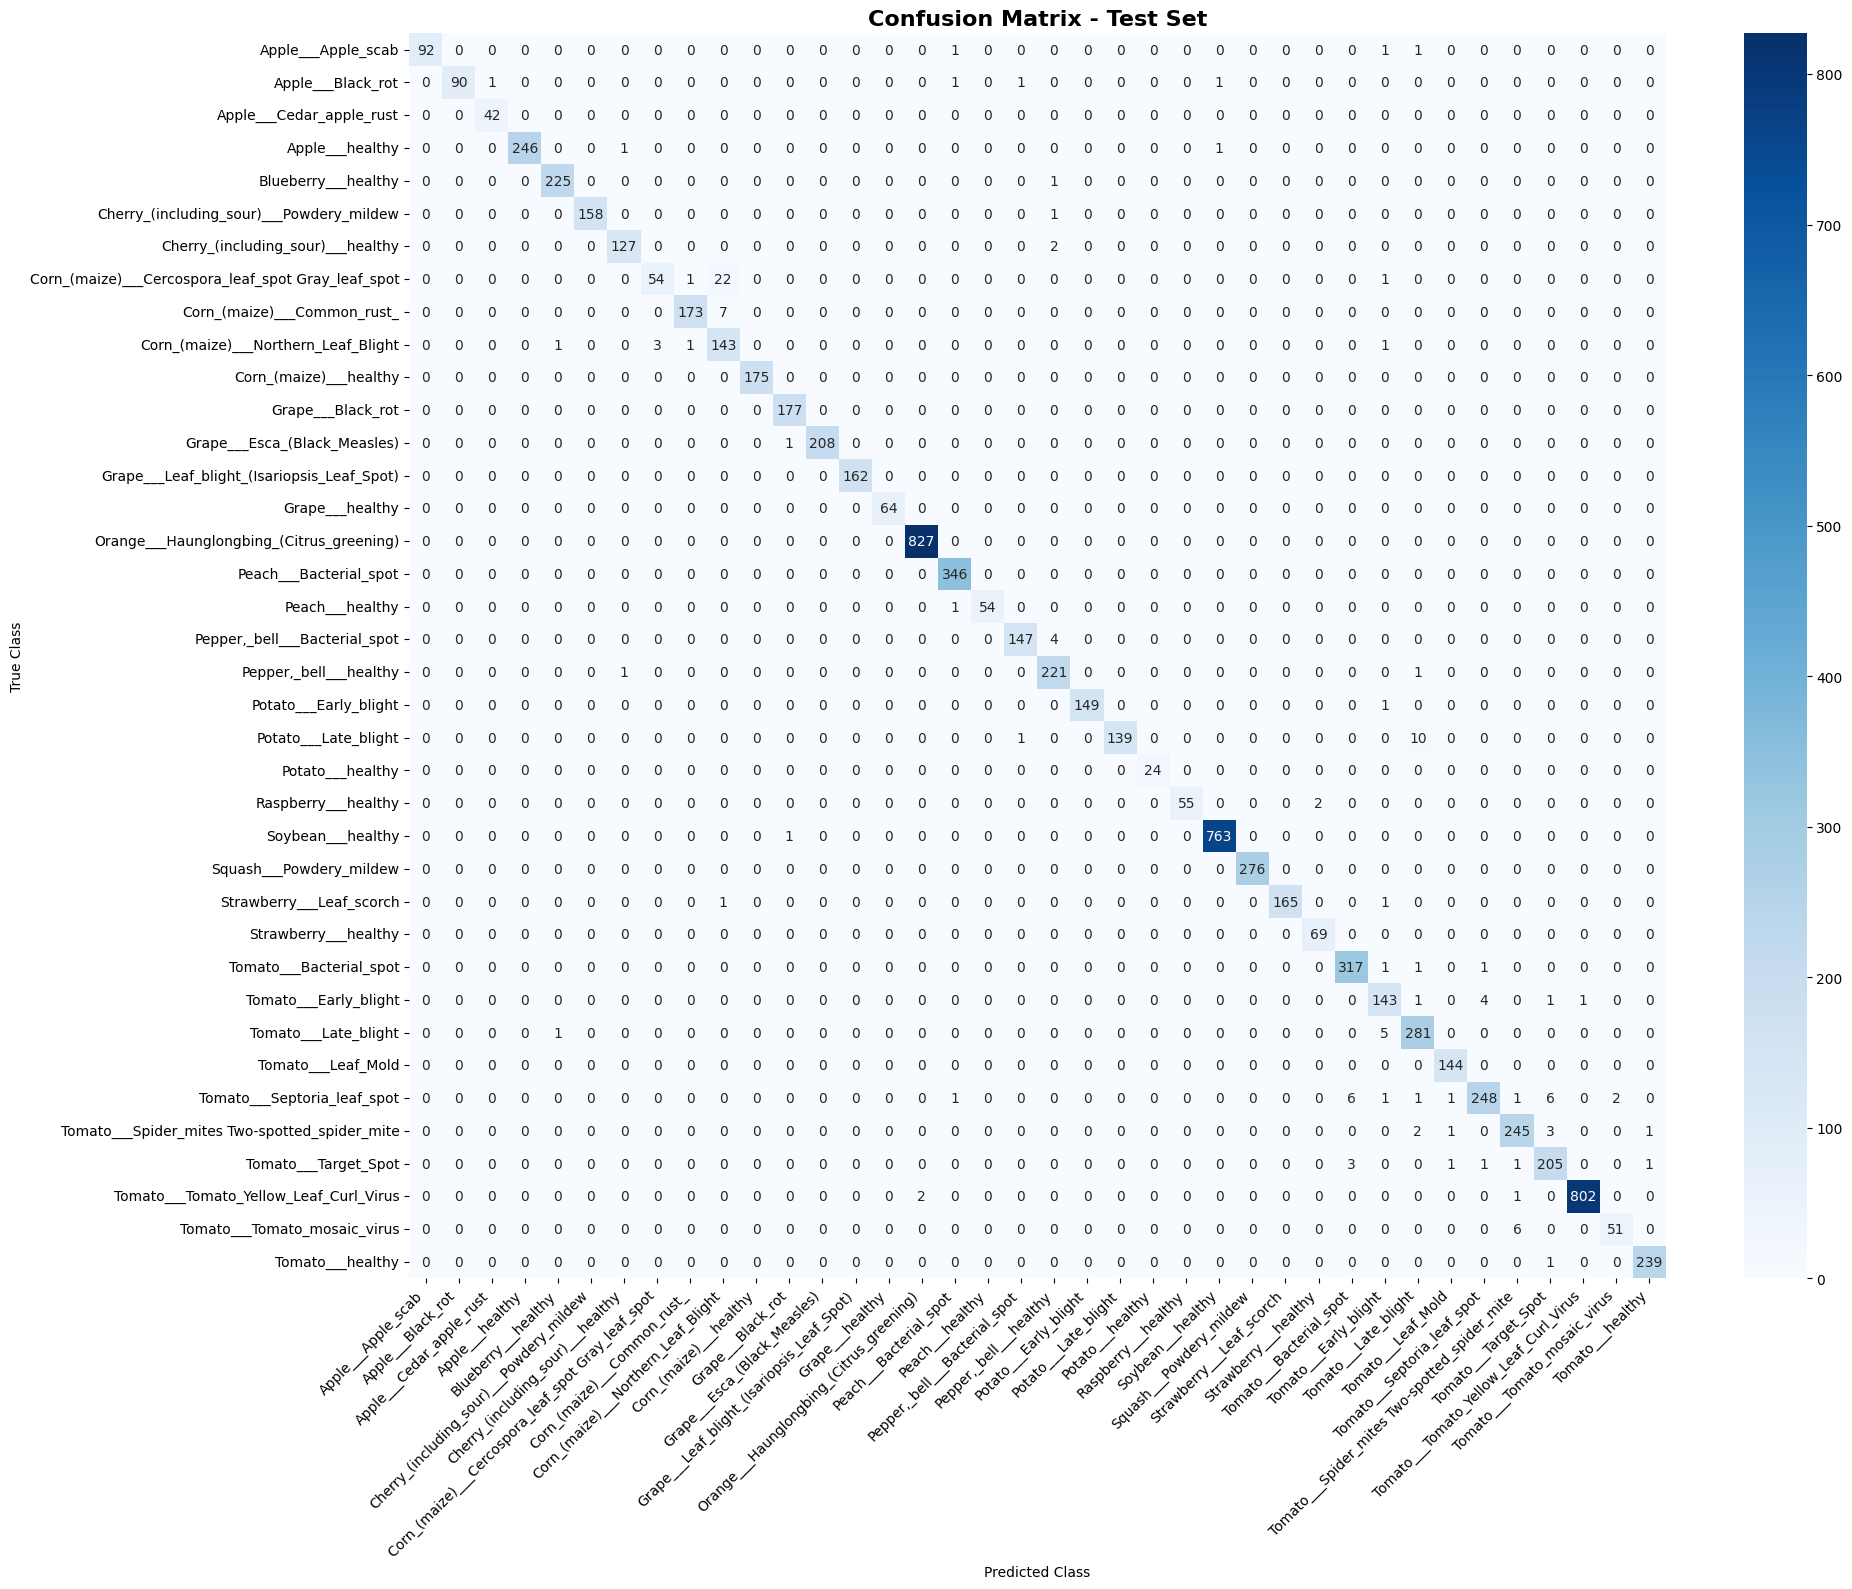


📊 Detailed Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9684    0.9840        95
                                 Apple___Black_rot     1.0000    0.9574    0.9783        94
                          Apple___Cedar_apple_rust     0.9767    1.0000    0.9882        42
                                   Apple___healthy     1.0000    0.9919    0.9960       248
                               Blueberry___healthy     0.9912    0.9956    0.9934       226
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9937    0.9968       159
                 Cherry_(including_sour)___healthy     0.9845    0.9845    0.9845       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9474    0.6923    0.8000        78
                       Corn_(maize)___Common_rust_     0.9886    0.9611    0.9746       180
               Corn_(maize)___Northern_Leaf_

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print_section("CONFUSION MATRIX & CLASSIFICATION REPORT")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
print("\n📊 Detailed Classification Report:")
print(classification_report(all_labels, all_preds, 
                           target_names=train_dataset.classes,
                           digits=4))